In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import CalibratedClassifierCV
import statsmodels.api as sm

In [2]:
df = pd.read_csv('C:/Users/ishee/Downloads/LFS_5year_data (1).csv')
print(df)

        location  gender  age  age^2  disability1  disability2  disability3  \
0              1       1   38   1444            0            0            0   
1              1       1   36   1296            0            0            0   
2              1       1   36   1296            0            0            0   
3              1       1   32   1024            0            0            0   
4              1       1   39   1521            0            0            0   
...          ...     ...  ...    ...          ...          ...          ...   
148972         1       0    6     36            0            0            0   
148973         1       1    9     81            0            0            0   
148974         0       1    8     64            0            0            0   
148975         0       0    4     16            0            0            0   
148976         1       0   11    121            0            0            0   

        disability4  disability5  disability6  marr

In [5]:
X = df.drop('employment', axis=1)
y = df['employment']
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
#1 Logistic regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [8]:
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # AUC-д ашиглана

In [11]:
print("=== Logistic Regression Үр дүн ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Logistic Regression Үр дүн ===
Confusion Matrix:
[[23547  1269]
 [ 2854  2126]]

Accuracy: 0.8616257215733656

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92     24816
           1       0.63      0.43      0.51      4980

    accuracy                           0.86     29796
   macro avg       0.76      0.69      0.71     29796
weighted avg       0.85      0.86      0.85     29796



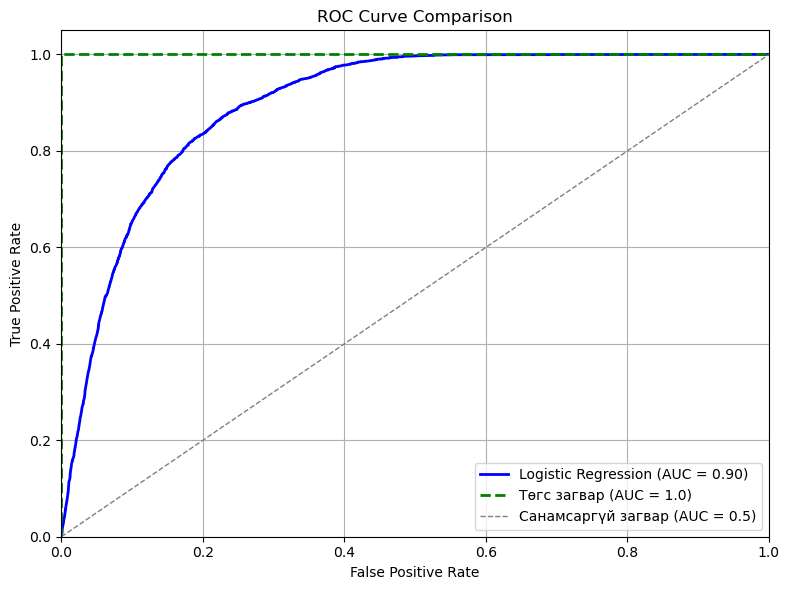

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 0, 1], [0, 1, 1], color='green', linestyle='--', lw=2, label='Төгс загвар (AUC = 1.0)')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Санамсаргүй загвар (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
#2 Decision tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [16]:
y_pred = dt_model.predict(X_test_scaled)
y_pred_proba = dt_model.predict_proba(X_test_scaled)[:, 1]

In [80]:
print("=== Decision Tree Үр дүн ===")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== Decision Tree Үр дүн ===

Confusion Matrix:
 [[23557  1259]
 [ 2850  2130]]
Accuracy: 0.8620955832997718

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92     24816
           1       0.63      0.43      0.51      4980

    accuracy                           0.86     29796
   macro avg       0.76      0.69      0.71     29796
weighted avg       0.85      0.86      0.85     29796



ROC AUC Score: 0.877786925425752


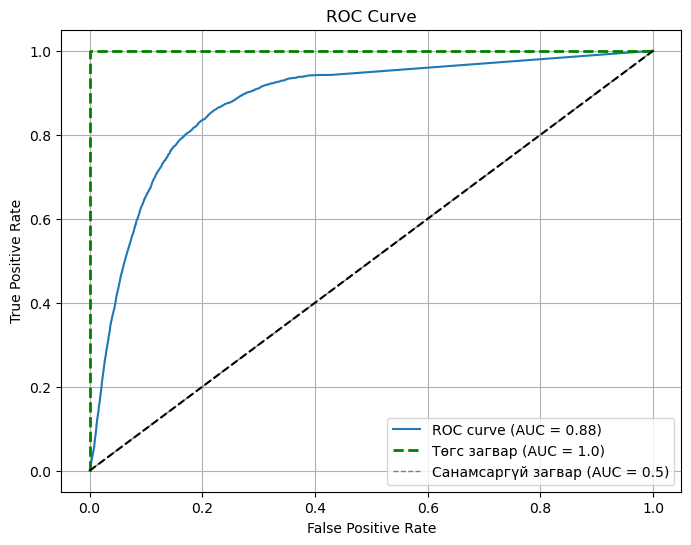

In [21]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print("ROC AUC Score:", roc_auc)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 0, 1], [0, 1, 1], color='green', linestyle='--', lw=2, label='Төгс загвар (AUC = 1.0)')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Санамсаргүй загвар (AUC = 0.5)')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [23]:
#3 Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [24]:
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

In [25]:
print("=== Random Forest Үр дүн ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Random Forest Үр дүн ===
Confusion Matrix:
[[23211  1605]
 [ 2372  2608]]

Accuracy: 0.8665257081487447

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92     24816
           1       0.62      0.52      0.57      4980

    accuracy                           0.87     29796
   macro avg       0.76      0.73      0.74     29796
weighted avg       0.86      0.87      0.86     29796



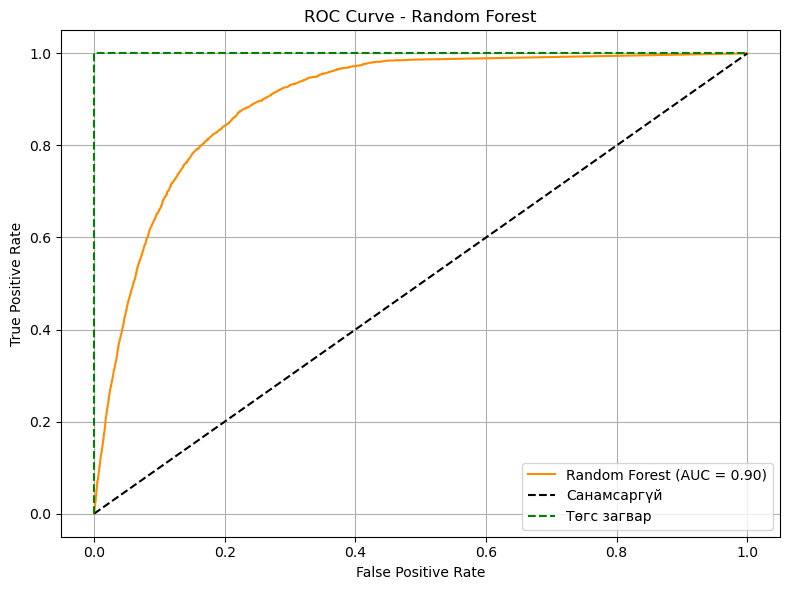

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.2f})", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label="Санамсаргүй")
plt.plot([0, 0, 1], [0, 1, 1], 'g--', label="Төгс загвар")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
#4 Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

GaussianNB()

In [28]:
y_pred = nb_model.predict(X_test_scaled)
y_prob = nb_model.predict_proba(X_test_scaled)[:, 1]

In [29]:
print("=== Naive Bayes Үр дүн ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Naive Bayes Үр дүн ===
Confusion Matrix:
[[16358  8458]
 [  456  4524]]

Accuracy: 0.7008323264867767

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.66      0.79     24816
           1       0.35      0.91      0.50      4980

    accuracy                           0.70     29796
   macro avg       0.66      0.78      0.64     29796
weighted avg       0.87      0.70      0.74     29796



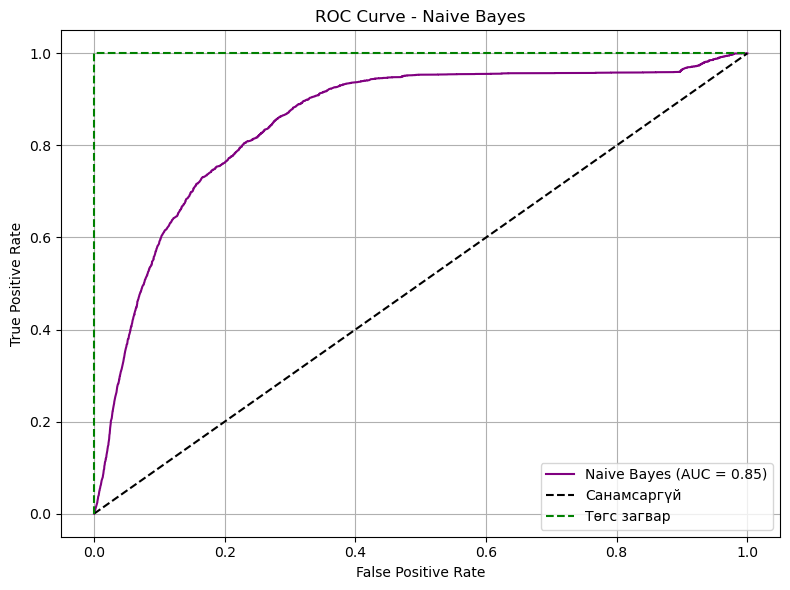

In [30]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Naive Bayes (AUC = {roc_auc:.2f})", color='purple')
plt.plot([0, 1], [0, 1], 'k--', label="Санамсаргүй")
plt.plot([0, 0, 1], [0, 1, 1], 'g--', label="Төгс загвар")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
#5 KNN загвар
knn_model = KNeighborsClassifier(n_neighbors=5)  # k=5, хүсвэл өөрчилж болно
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [32]:
y_pred = knn_model.predict(X_test_scaled)
y_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

In [33]:
print("=== K-Nearest Neighbors Үр дүн ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== K-Nearest Neighbors Үр дүн ===
Confusion Matrix:
[[23045  1771]
 [ 2610  2370]]

Accuracy: 0.8529668411867365

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     24816
           1       0.57      0.48      0.52      4980

    accuracy                           0.85     29796
   macro avg       0.74      0.70      0.72     29796
weighted avg       0.84      0.85      0.85     29796



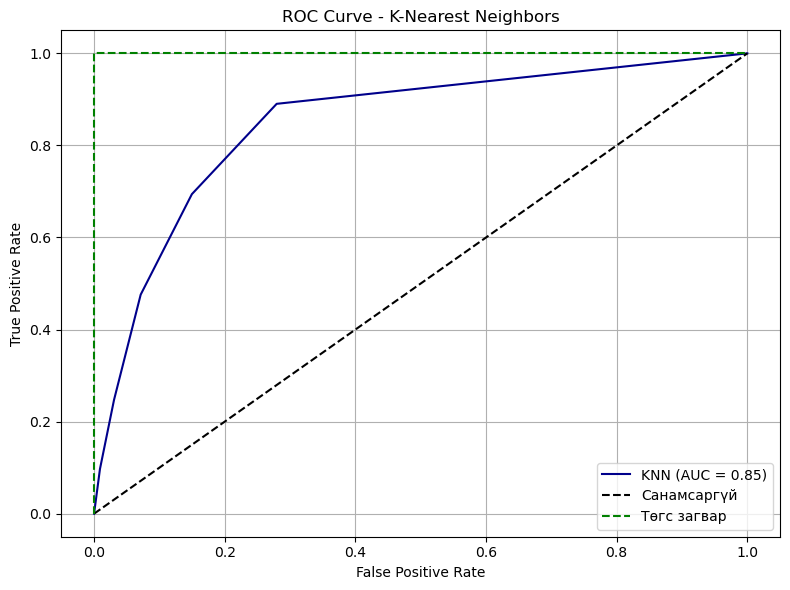

In [34]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"KNN (AUC = {roc_auc:.2f})", color='darkblue')
plt.plot([0, 1], [0, 1], 'k--', label="Санамсаргүй")
plt.plot([0, 0, 1], [0, 1, 1], 'g--', label="Төгс загвар")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - K-Nearest Neighbors")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
#6 LinearSVC загвар + магадлалын тохиргоотой
base_model = LinearSVC(max_iter=5000, class_weight='balanced', random_state=42)
svc_model = CalibratedClassifierCV(base_model, cv=3)  # probability гаргаж чаддаг болгоно
svc_model.fit(X_train_scaled, y_train)

CalibratedClassifierCV(cv=3,
                       estimator=LinearSVC(class_weight='balanced',
                                           max_iter=5000, random_state=42))

In [36]:
y_pred = svc_model.predict(X_test_scaled)
y_scores = svc_model.predict_proba(X_test_scaled)[:, 1]

In [37]:
print("=== Linear SVC Үр дүн ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Linear SVC Үр дүн ===
Confusion Matrix:
[[23557  1259]
 [ 2850  2130]]

Accuracy: 0.8620955832997718

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92     24816
           1       0.63      0.43      0.51      4980

    accuracy                           0.86     29796
   macro avg       0.76      0.69      0.71     29796
weighted avg       0.85      0.86      0.85     29796



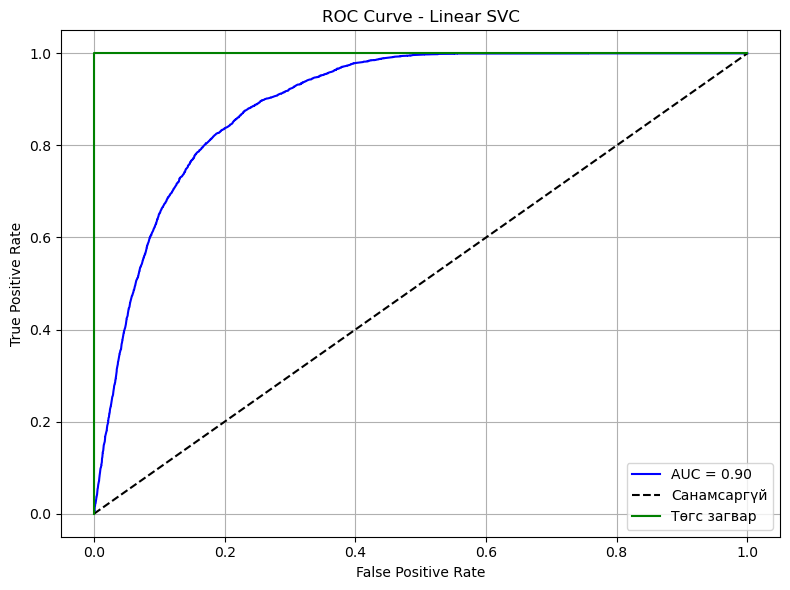

In [38]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='blue')
plt.plot([0, 1], [0, 1], 'k--', label="Санамсаргүй")
plt.plot([0, 0, 1], [0, 1, 1], 'g-', label="Төгс загвар")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Linear SVC")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

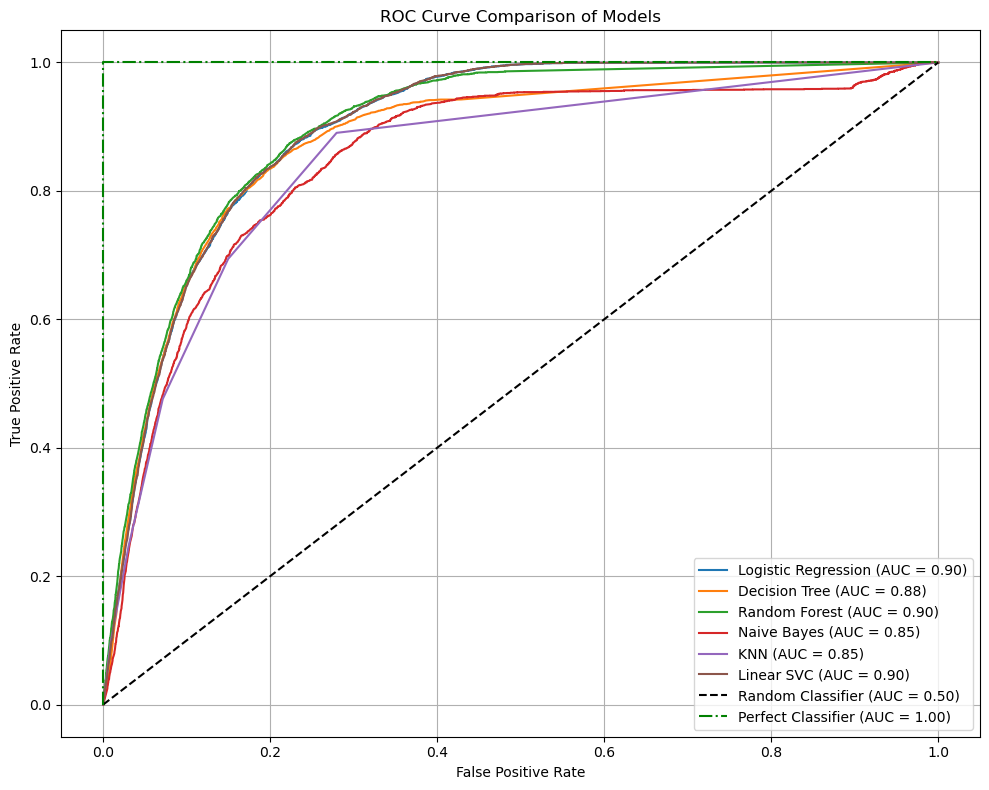

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Загваруудын нэр ба объект
models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Naive Bayes": nb_model,
    "KNN": knn_model,
    "Linear SVC": svc_model
}

# ROC муруй зурна
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Probability оноо авах
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# 🟡 Санамсаргүй загвар (random classifier): шууд диагональ
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)', linewidth=1.5)

# 🟢 Төгс загвар (perfect classifier): 0,1 -> 0,1 муруй
plt.plot([0, 0, 1], [0, 1, 1], 'g-.', label='Perfect Classifier (AUC = 1.00)', linewidth=1.5)

# График тохиргоо
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [40]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Загваруудыг дахин нэгтгэнэ
models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Naive Bayes": nb_model,
    "KNN": knn_model,
    "Linear SVC": svc_model
}

# Үр дүн хадгалах
results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": [],
    "AUC": []
}

# Үнэлгээ хийх
for name, model in models.items():
    # Prediction ба probability
    y_pred = model.predict(X_test_scaled)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)

    # Үнэлгээ тооцох
    results["Model"].append(name)
    results["Accuracy"].append(accuracy_score(y_test, y_pred))
    results["Precision"].append(precision_score(y_test, y_pred))
    results["Recall"].append(recall_score(y_test, y_pred))
    results["F1 Score"].append(f1_score(y_test, y_pred))
    results["AUC"].append(roc_auc_score(y_test, y_prob))

# DataFrame үүсгэх ба форматлах
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="AUC", ascending=False)
display(results_df.round(3))

,Model,Accuracy,Precision,Recall,F1 Score,AUC
2,Random Forest,0.867,0.619,0.524,0.567,0.897
5,Linear SVC,0.862,0.629,0.428,0.509,0.897
0,Logistic Regression,0.862,0.626,0.427,0.508,0.897
1,Decision Tree,0.864,0.612,0.515,0.559,0.878
3,Naive Bayes,0.701,0.348,0.908,0.504,0.852
4,KNN,0.853,0.572,0.476,0.520,0.849


In [76]:
# Сангуудыг импортлох
import statsmodels.api as sm

# Дата унших
data = pd.read_csv('C:/Users/ishee/Downloads/LFS_5year_data (1).csv')

# Хамаарах хувьсагч (X), хамаарагдах хувьсагч (y) тодорхойлох
X = data.drop('employment', axis=1)
y = data['employment']

# Констант нэмэх (intercept нэмэх)
X = sm.add_constant(X)

# ===== Logit загвар =====
logit_model = sm.Logit(y, X)
logit_result = logit_model.fit()

print("\n=== Logit Model Summary ===")
print(logit_result.summary())

# Logit загварын ахиу нөлөө
marginal_effects_logit = logit_result.get_margeff()
print("\n=== Logit Model Marginal Effects ===")
print(marginal_effects_logit.summary())


# ===== Probit загвар =====
probit_model = sm.Probit(y, X)
probit_result = probit_model.fit()

print("\n=== Probit Model Summary ===")
print(probit_result.summary())

# Probit загварын ахиу нөлөө
marginal_effects_probit = probit_result.get_margeff()
print("\n=== Probit Model Marginal Effects ===")
print(marginal_effects_probit.summary())

Optimization terminated successfully.
         Current function value: 0.287019
         Iterations 9

=== Logit Model Summary ===
                           Logit Regression Results                           
Dep. Variable:             employment   No. Observations:               148977
Model:                          Logit   Df Residuals:                   148963
Method:                           MLE   Df Model:                           13
Date:                Sat, 03 May 2025   Pseudo R-squ.:                  0.3623
Time:                        18:42:13   Log-Likelihood:                -42759.
converged:                       True   LL-Null:                       -67052.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -9.7581      0.088   -111.072      0.000      -9.930      -9.5

In [42]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

In [43]:
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [44]:
print(feature_importance_df)

        Feature  Importance
11    education    0.368515
3         age^2    0.223184
2           age    0.218971
10      married    0.053952
0      location    0.044628
1        gender    0.025748
6   disability3    0.016108
4   disability1    0.012712
12     training    0.010863
5   disability2    0.009674
7   disability4    0.007128
8   disability5    0.004884
9   disability6    0.003633


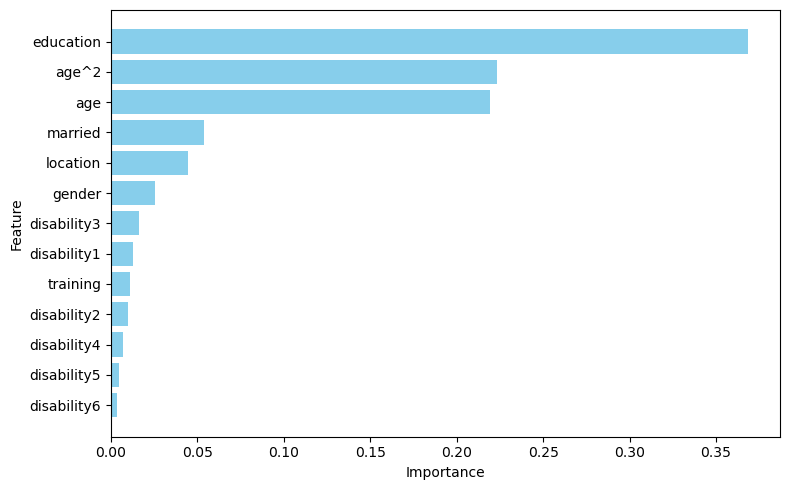

In [45]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

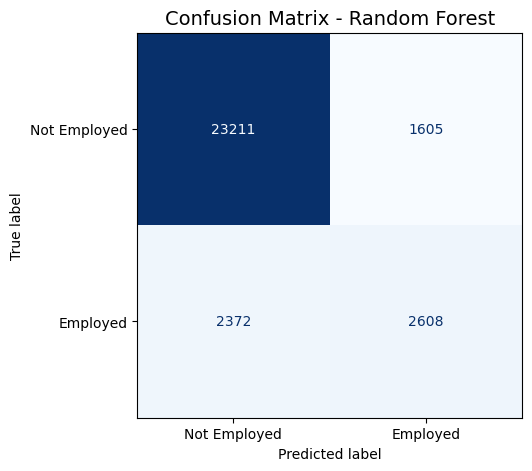

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Confusion matrix өгөгдөл
cm = np.array([[23211, 1605],
               [2372, 2608]])

# График дүрслэл
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Employed", "Employed"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
plt.title("Confusion Matrix - Random Forest", fontsize=14)
plt.show()


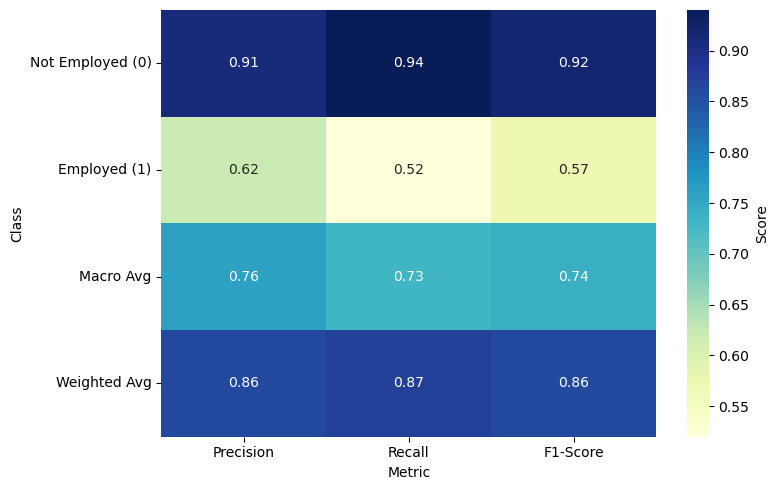

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Classification report өгөгдлийг гар аргаар оруулсан
report_data = {
    'Class': ['Not Employed (0)', 'Employed (1)', 'Macro Avg', 'Weighted Avg'],
    'Precision': [0.91, 0.62, 0.76, 0.86],
    'Recall': [0.94, 0.52, 0.73, 0.87],
    'F1-Score': [0.92, 0.57, 0.74, 0.86],
    'Support': [24816, 4980, 29796, 29796]
}

df_report = pd.DataFrame(report_data)
df_metrics = df_report.drop(columns=['Class', 'Support'])
df_metrics.index = df_report['Class']

# Heatmap зурж харуулах
plt.figure(figsize=(8, 5))
sns.heatmap(df_metrics, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Score'})
plt.xlabel("Metric")
plt.ylabel("Class")
plt.tight_layout()
plt.show()
